In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
df = pd.read_csv("catalyst_data.csv")
df.head()

,Metal,SurfaceArea,BandGap,ParticleSize,PoreVolume,Temperature,pH,Time,Activity
0,Cu,120,2.1,25,0.45,30,7,60,82
1,Cu,130,2.0,22,0.48,40,7,60,86
2,Co,150,2.3,18,0.60,35,6,90,89
3,Ni,110,2.5,28,0.40,25,8,45,75
4,Zn,90,3.0,35,0.30,30,7,60,68


In [9]:
df = pd.read_csv("catalyst_data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Metal         15 non-null     str    
 1   SurfaceArea   15 non-null     int64  
 2   BandGap       15 non-null     float64
 3   ParticleSize  15 non-null     int64  
 4   PoreVolume    15 non-null     float64
 5   Temperature   15 non-null     int64  
 6   pH            15 non-null     int64  
 7   Time          15 non-null     int64  
 8   Activity      15 non-null     int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 1.2 KB


In [10]:
df.describe()

,SurfaceArea,BandGap,ParticleSize,PoreVolume,Temperature,pH,Time,Activity
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,143.666667,2.466667,21.333333,0.554667,36.666667,6.600000,79.000000,84.800000
std,35.328391,0.379222,7.631389,0.160173,8.164966,0.910259,22.614787,9.473271
min,90.000000,2.000000,10.000000,0.300000,25.000000,5.000000,45.000000,68.000000
25%,117.500000,2.150000,15.500000,0.435000,30.000000,6.000000,60.000000,78.500000
50%,140.000000,2.400000,20.000000,0.550000,35.000000,7.000000,75.000000,86.000000
75%,165.000000,2.750000,26.500000,0.675000,42.500000,7.000000,90.000000,92.500000
max,210.000000,3.100000,35.000000,0.820000,50.000000,8.000000,120.000000,97.000000


In [11]:
df.isnull

<bound method DataFrame.isnull of    Metal  SurfaceArea  BandGap  ParticleSize  PoreVolume  Temperature  pH  \
0     Cu          120      2.1            25        0.45           30   7   
1     Cu          130      2.0            22        0.48           40   7   
2     Co          150      2.3            18        0.60           35   6   
3     Ni          110      2.5            28        0.40           25   8   
4     Zn           90      3.0            35        0.30           30   7   
5     Fe          170      2.2            16        0.65           40   6   
6     Mn          140      2.4            20        0.55           35   7   
7     Ti          200      3.1            12        0.80           45   5   
8     Cu          160      2.0            15        0.70           50   6   
9     Co          145      2.3            19        0.58           35   7   
10    Ni          115      2.6            30        0.42           25   8   
11    Zn          100      2.9            

In [12]:
df.isnull().sum()

Metal           0
SurfaceArea     0
BandGap         0
ParticleSize    0
PoreVolume      0
Temperature     0
pH              0
Time            0
Activity        0
dtype: int64

In [13]:
encoder = LabelEncoder()
df["Metal"] = encoder.fit_transform(df["Metal"])
df.head()

,Metal,SurfaceArea,BandGap,ParticleSize,PoreVolume,Temperature,pH,Time,Activity
0,1,120,2.1,25,0.45,30,7,60,82
1,1,130,2.0,22,0.48,40,7,60,86
2,0,150,2.3,18,0.60,35,6,90,89
3,4,110,2.5,28,0.40,25,8,45,75
4,6,90,3.0,35,0.30,30,7,60,68


In [14]:
print(dict(zip(encoder.classes_,
               encoder.transform(encoder.classes_))))

{'Co': np.int64(0), 'Cu': np.int64(1), 'Fe': np.int64(2), 'Mn': np.int64(3), 'Ni': np.int64(4), 'Ti': np.int64(5), 'Zn': np.int64(6)}


In [16]:
# Input features
X = df.drop("Activity", axis=1)

# Target variable
y = df["Activity"]
print(X.shape)
print(y.shape)

(15, 8)
(15,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(12, 8)
(3, 8)


In [18]:
# Create the model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [19]:
# Predict catalyst activity
y_pred = model.predict(X_test)

print(y_pred)

[86.01 70.31 76.82]


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 2.4933333333333345
R² Score: 0.8161392857142854


In [21]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results)

    Actual  Predicted
9       88      86.01
11      70      70.31
0       82      76.82


In [22]:
print("MAE:", mae)
print("R²:", r2)

MAE: 2.4933333333333345
R²: 0.8161392857142854


In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

        Feature  Importance
1   SurfaceArea    0.251663
3  ParticleSize    0.191862
4    PoreVolume    0.191112
5   Temperature    0.166307
7          Time    0.120450
6            pH    0.041633
0         Metal    0.022871
2       BandGap    0.014102


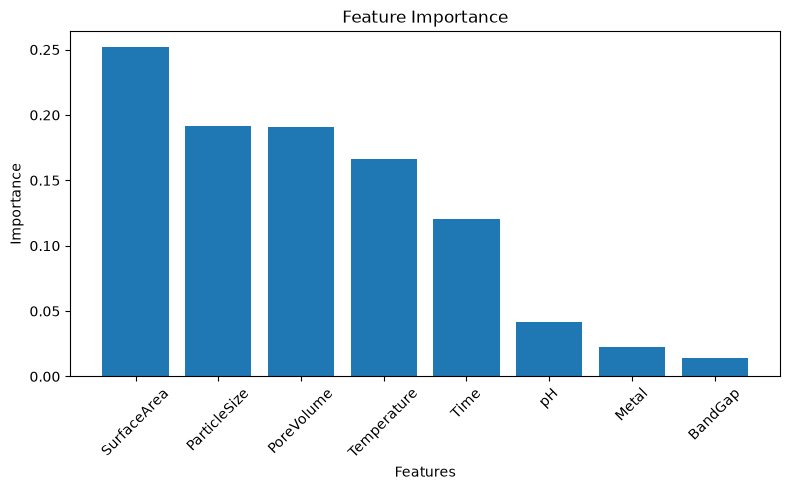

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()
plt.show()

In [26]:
print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))
new_catalyst = pd.DataFrame({
    "Metal": [1],          # Replace with the correct encoded value if needed
    "SurfaceArea": [155],
    "BandGap": [2.1],
    "ParticleSize": [18],
    "PoreVolume": [0.62],
    "Temperature": [40],
    "pH": [6],
    "Time": [90]
})

prediction = model.predict(new_catalyst)

print("Predicted Activity:", prediction[0])

{'Co': np.int64(0), 'Cu': np.int64(1), 'Fe': np.int64(2), 'Mn': np.int64(3), 'Ni': np.int64(4), 'Ti': np.int64(5), 'Zn': np.int64(6)}
Predicted Activity: 89.95


In [28]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn installed successfully")

Seaborn installed successfully


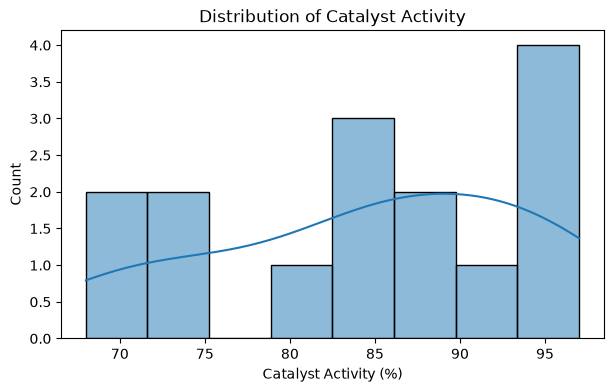

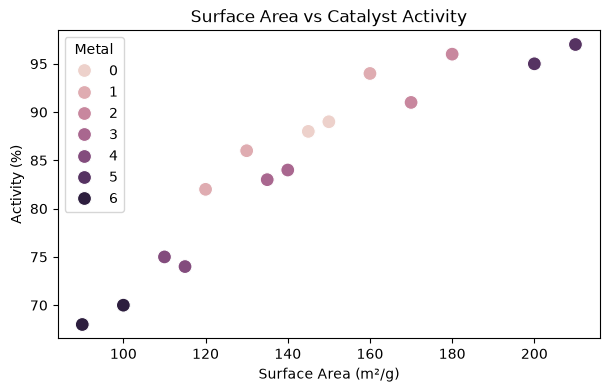

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))

sns.histplot(
    df["Activity"],
    bins=8,
    kde=True
)

plt.xlabel("Catalyst Activity (%)")
plt.ylabel("Count")
plt.title("Distribution of Catalyst Activity")

plt.show()
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df,
    x="SurfaceArea",
    y="Activity",
    hue="Metal",
    s=100
)

plt.xlabel("Surface Area (m²/g)")
plt.ylabel("Activity (%)")
plt.title("Surface Area vs Catalyst Activity")

plt.show()

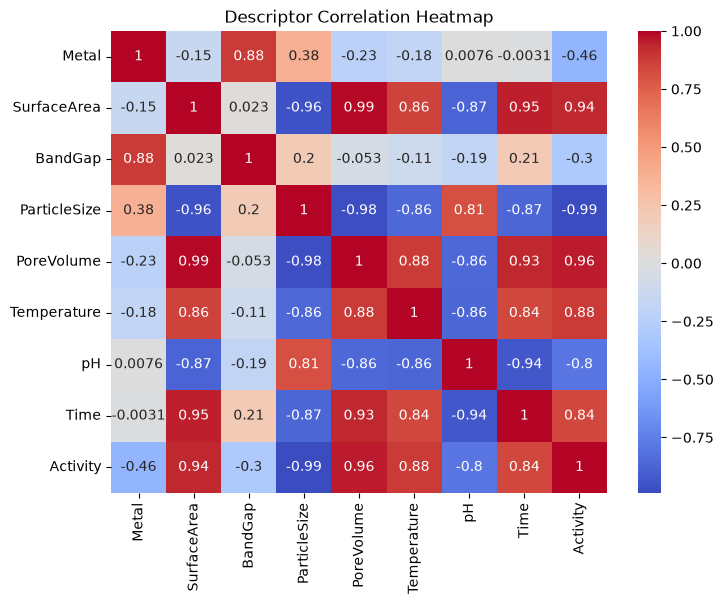

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Descriptor Correlation Heatmap")

plt.show()

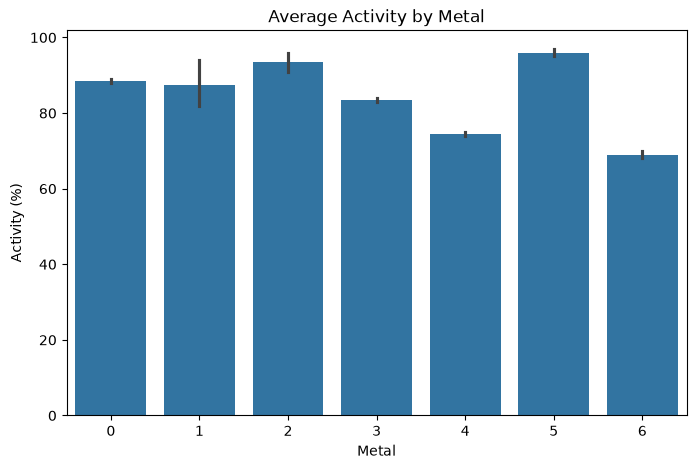

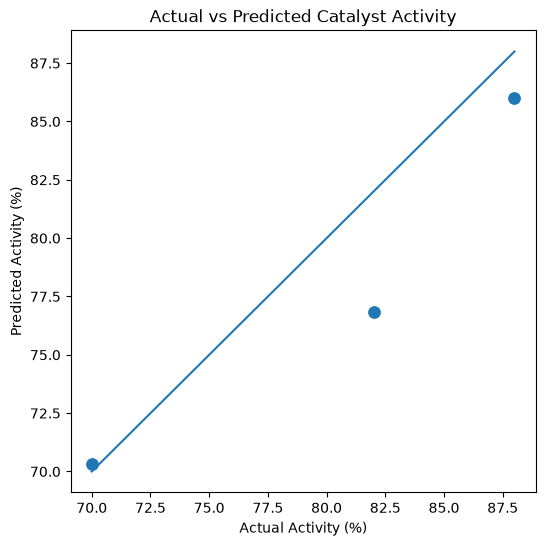

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Metal",
    y="Activity"
)

plt.xlabel("Metal")
plt.ylabel("Activity (%)")
plt.title("Average Activity by Metal")

plt.show()
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
plt.figure(figsize=(6,6))

sns.scatterplot(
    data=prediction_df,
    x="Actual",
    y="Predicted",
    s=100
)

plt.plot(
    [prediction_df["Actual"].min(),
     prediction_df["Actual"].max()],
    [prediction_df["Actual"].min(),
     prediction_df["Actual"].max()]
)

plt.xlabel("Actual Activity (%)")
plt.ylabel("Predicted Activity (%)")
plt.title("Actual vs Predicted Catalyst Activity")

plt.show()

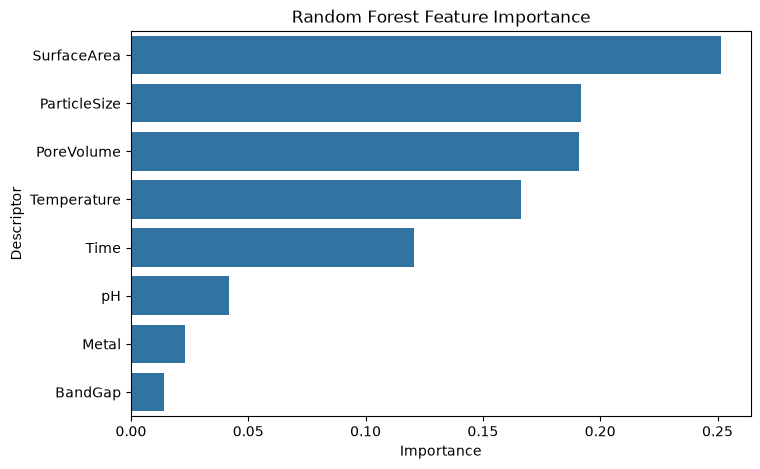

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Descriptor")

plt.show()

In [38]:
import joblib

joblib.dump(model, "catalyst_model.pkl")
joblib.dump(encoder, "metal_encoder.pkl")

['metal_encoder.pkl']

In [35]:
!pip install joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys

print(sys.executable)

c:\Users\Asad\OneDrive\Desktop\Computational_Chemistry\compchem_env\Scripts\python.exe


In [39]:
import joblib

joblib.dump(model, "catalyst_model.pkl")
joblib.dump(encoder, "metal_encoder.pkl")
import streamlit as st
import pandas as pd
import joblib


# Load model
model = joblib.load("catalyst_model.pkl")
encoder = joblib.load("metal_encoder.pkl")


st.title("Catalyst Activity Prediction")

st.write(
    "Predict catalyst activity using machine learning descriptors"
)


metal = st.selectbox(
    "Metal",
    encoder.classes_
)

surface_area = st.number_input(
    "Surface Area (m²/g)",
    value=150
)

band_gap = st.number_input(
    "Band Gap (eV)",
    value=2.1
)

particle_size = st.number_input(
    "Particle Size (nm)",
    value=20
)

pore_volume = st.number_input(
    "Pore Volume",
    value=0.6
)

temperature = st.number_input(
    "Temperature (°C)",
    value=40
)

pH = st.number_input(
    "pH",
    value=7
)

time = st.number_input(
    "Reaction Time (min)",
    value=90
)


if st.button("Predict Activity"):

    metal_encoded = encoder.transform([metal])[0]

    new_data = pd.DataFrame({
        "Metal":[metal_encoded],
        "SurfaceArea":[surface_area],
        "BandGap":[band_gap],
        "ParticleSize":[particle_size],
        "PoreVolume":[pore_volume],
        "Temperature":[temperature],
        "pH":[pH],
        "Time":[time]
    })


    prediction = model.predict(new_data)

    st.success(
        f"Predicted Activity: {prediction[0]:.2f}%"
    )

2026-07-30 17:18:15.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.680 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 17:18:15.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar